# Brazilian E-Commerce Sales Analysis
## Introduction

The Olist Brazilian E-Commerce dataset contains over 100,000 real orders placed
on the Olist platform between 2016 and 2018. It covers order status, payment
methods, customer reviews, product categories, and delivery times across
multiple Brazilian states.

This project uses descriptive statistics and visualizations to explore which product categories generate the most revenue, how customer satisfaction varies across categories, whether delivery time affects review scores, and which states have the highest order volumes and average spending.
## How to use this notebook

first, Clone this repository and install the required libraries:

pip install pandas matplotlib seaborn python-dotenv requests

You also need to create a `.env` file in the root folder and add your API key:

OPENWEATHER_API_KEY=your_API_key

Run all cells from top to bottom (Run All)


## Data pipeline overview
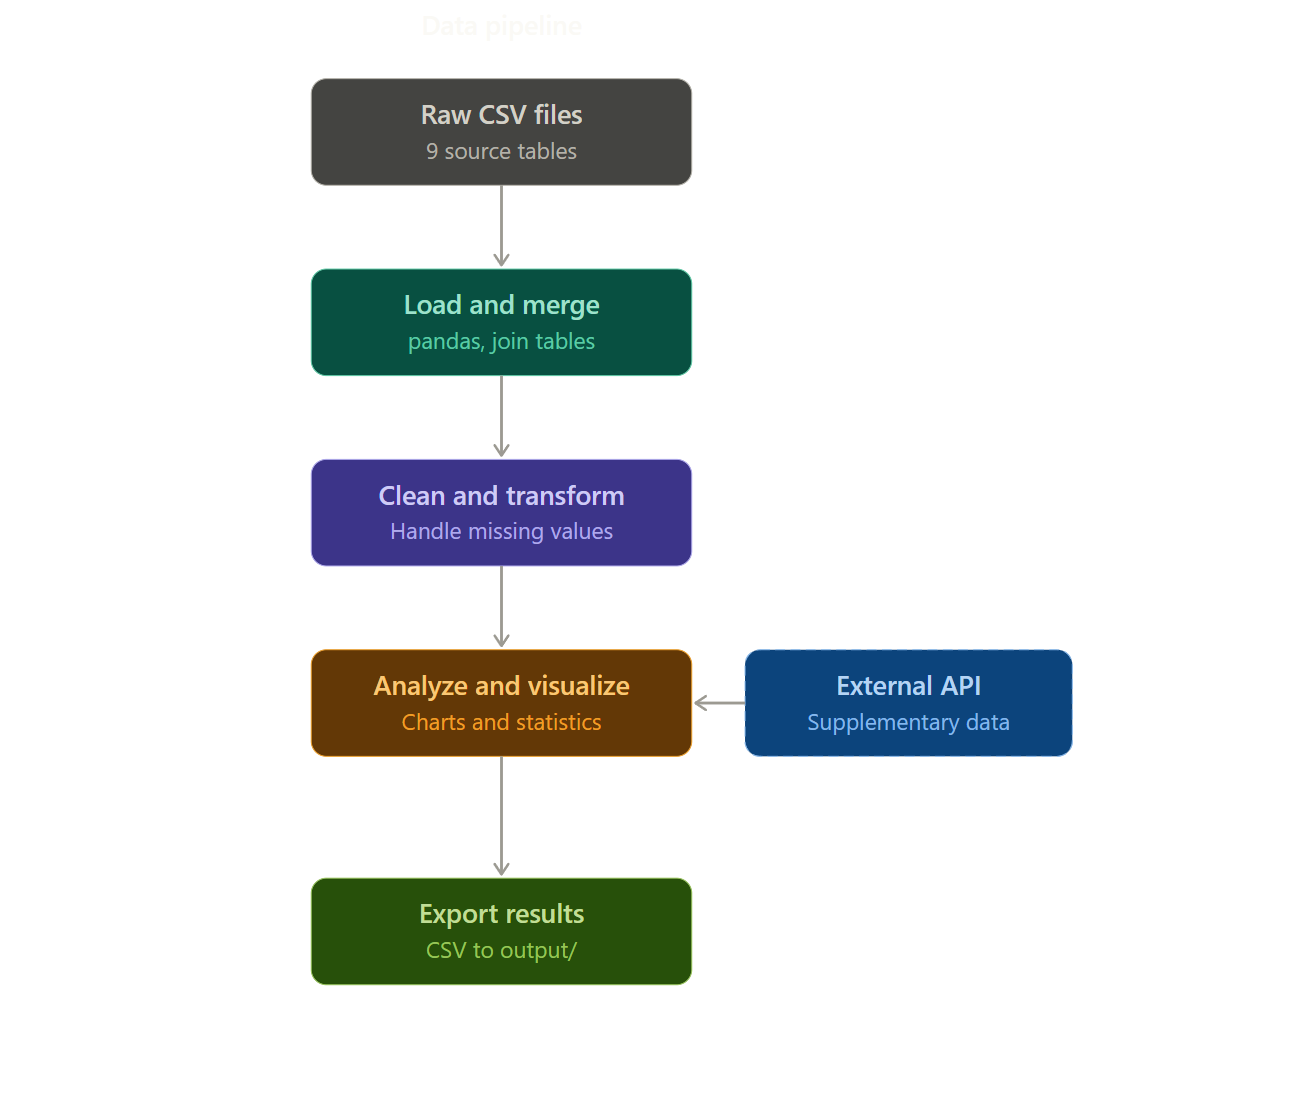

In [46]:
#data loading
import pandas as pd
import os
data_path="data/raw"
orders = pd.read_csv(os.path.join(data_path, "olist_orders_dataset.csv"))
order_items = pd.read_csv(os.path.join(data_path, "olist_order_items_dataset.csv"))
payments = pd.read_csv(os.path.join(data_path, "olist_order_payments_dataset.csv"))
reviews = pd.read_csv(os.path.join(data_path, "olist_order_reviews_dataset.csv"))
customers = pd.read_csv(os.path.join(data_path, "olist_customers_dataset.csv"))
products = pd.read_csv(os.path.join(data_path, "olist_products_dataset.csv"))
category_translation = pd.read_csv(os.path.join(data_path, "product_category_name_translation.csv"))

print("Tables loaded successfully")

Tables loaded successfully


In [47]:
#data merging
df = orders.merge(customers, on="customer_id", how="left")
df = df.merge(order_items, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(category_translation, on="product_category_name", how="left")
df = df.merge(payments, on="order_id", how="left")
df = df.merge(reviews, on="order_id", how="left")
print(f"number of rows and columns: {df.shape}")
display(df.head())

number of rows and columns: (119143, 37)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58


In [48]:
os.makedirs("data", exist_ok=True)
df.to_csv("data/raw_merged.csv",index=False)
print("Raw merged data saved")

Raw merged data saved


In [49]:
#this cell is refined by claude ai, I didn't think about the issue.
# If you do not have the original CSV files, load the saved merged data instead:
# df = pd.read_csv("data/raw_merged.csv")
# display(df.head())

In [50]:
#cleaning data
#delete useless columns
cols_to_drop = [
    "review_comment_title", "review_comment_message",
    "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm",
    "product_name_lenght", "product_description_lenght", "product_photos_qty",
    "seller_id", "payment_sequential", "payment_installments"
]
df = df.drop(columns=cols_to_drop)
print("missing value per column:")
display(df.isnull().sum()[df.isnull().sum()>0]) #check null value

missing value per column:


order_approved_at                 177
order_delivered_carrier_date     2086
order_delivered_customer_date    3421
order_item_id                     833
product_id                        833
shipping_limit_date               833
price                             833
freight_value                     833
product_category_name            2542
product_category_name_english    2567
payment_type                        3
payment_value                       3
review_id                         997
review_score                      997
review_creation_date              997
review_answer_timestamp           997
dtype: int64

In [51]:
#drop data that lacks of key values
df=df.dropna(subset=["price","review_score","product_category_name_english","order_delivered_customer_date","payment_value"]) 
print(f"number of rows and columns: {df.shape}")



number of rows and columns: (113209, 25)


In [52]:
# Convert time form
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# Calculate delivery time
df["delivery_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days #in days         

df["order_year_month"] = df["order_purchase_timestamp"].dt.to_period("M") #yea and month for analysis

print("Date columns converted")
display(df[["order_purchase_timestamp", "order_delivered_customer_date", "delivery_days"]].head())
print(f"number of rows and columns: {df.shape}")
display(df.head())


Date columns converted


,order_purchase_timestamp,order_delivered_customer_date,delivery_days
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8
1,2017-10-02 10:56:33,2017-10-10 21:25:13,8
2,2017-10-02 10:56:33,2017-10-10 21:25:13,8
3,2018-07-24 20:41:37,2018-08-07 15:27:45,13
4,2018-08-08 08:38:49,2018-08-17 18:06:29,9


number of rows and columns: (113209, 27)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_category_name,product_category_name_english,payment_type,payment_value,review_id,review_score,review_creation_date,review_answer_timestamp,delivery_days,order_year_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,utilidades_domesticas,housewares,credit_card,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11 00:00:00,2017-10-12 03:43:48,8,2017-10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,utilidades_domesticas,housewares,voucher,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11 00:00:00,2017-10-12 03:43:48,8,2017-10
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,utilidades_domesticas,housewares,voucher,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11 00:00:00,2017-10-12 03:43:48,8,2017-10
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,perfumaria,perfumery,boleto,141.46,8d5266042046a06655c8db133d120ba5,4.0,2018-08-08 00:00:00,2018-08-08 18:37:50,13,2018-07
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,automotivo,auto,credit_card,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,2018-08-18 00:00:00,2018-08-22 19:07:58,9,2018-08


In [53]:
#keep useful columns only
df = df[["order_id","customer_state","product_category_name_english","price","payment_value","review_score","delivery_days","order_year_month"]]
print(f"Final shape: {df.shape}")
display(df.head())

Final shape: (113209, 8)


,order_id,customer_state,product_category_name_english,price,payment_value,review_score,delivery_days,order_year_month
0,e481f51cbdc54678b7cc49136f2d6af7,SP,housewares,29.99,18.12,4.0,8,2017-10
1,e481f51cbdc54678b7cc49136f2d6af7,SP,housewares,29.99,2.00,4.0,8,2017-10
2,e481f51cbdc54678b7cc49136f2d6af7,SP,housewares,29.99,18.59,4.0,8,2017-10
3,53cdb2fc8bc7dce0b6741e2150273451,BA,perfumery,118.70,141.46,4.0,13,2018-07
4,47770eb9100c2d0c44946d9cf07ec65d,GO,auto,159.90,179.12,5.0,9,2018-08


In [54]:
#final check
print(df.dtypes)
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nReview score range: {df['review_score'].min()} to {df['review_score'].max()}")
print(f"Delivery days range: {df['delivery_days'].min()} to {df['delivery_days'].max()}")

order_id                            object
customer_state                      object
product_category_name_english       object
price                              float64
payment_value                      float64
review_score                       float64
delivery_days                        int64
order_year_month                 period[M]
dtype: object

Missing values: 0

Review score range: 1.0 to 5.0
Delivery days range: 0 to 208


In [55]:
#analyze and visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")


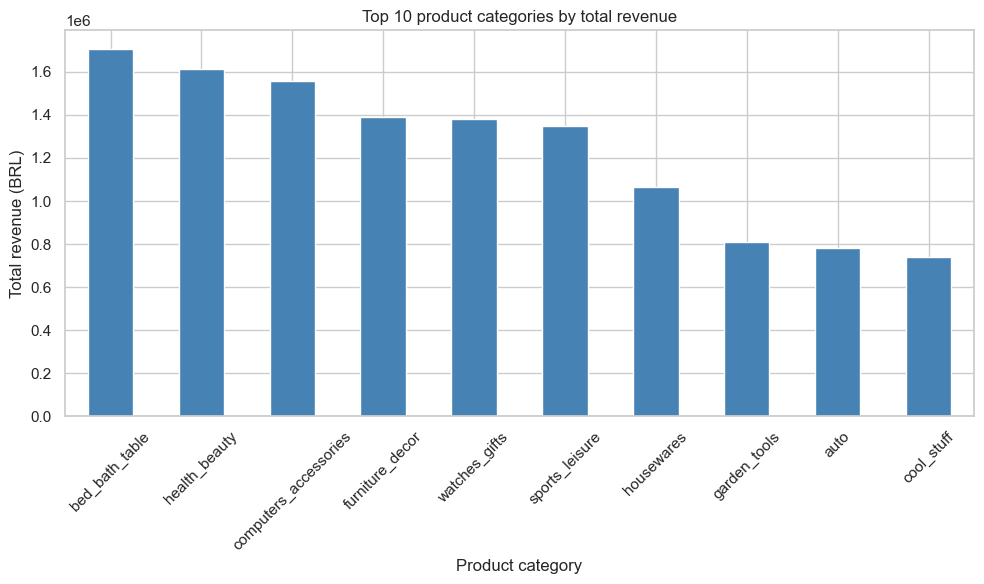

In [56]:
#top 10 total revenue/category
grouped = df.groupby("product_category_name_english")["payment_value"].sum() #total revenue/category
sorted_revenue = grouped.sort_values(ascending=False) #order
revenue_by_category = sorted_revenue.head(10) #keep top10

fig, ax = plt.subplots(figsize=(10, 6))
revenue_by_category.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Top 10 product categories by total revenue")
ax.set_xlabel("Product category")
ax.set_ylabel("Total revenue (BRL)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


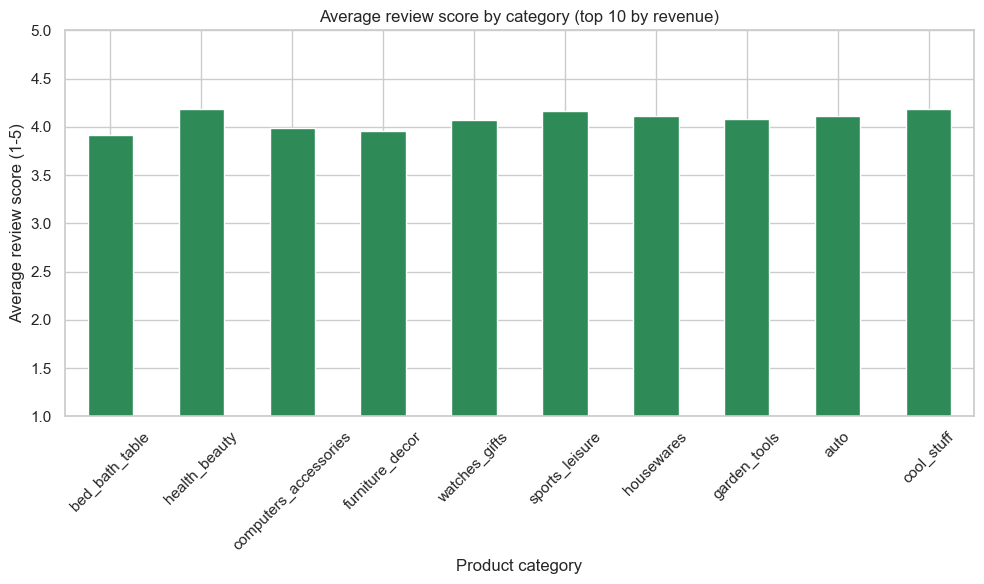

In [57]:
#average review score for top10 category
top_categories = revenue_by_category.index.tolist()

filtered = df[df["product_category_name_english"].isin(top_categories)]  #top_categories rows
grouped = filtered.groupby("product_category_name_english")["review_score"].mean() #ave-review score-category
avg_score = grouped.reindex(top_categories) #order

fig, ax = plt.subplots(figsize=(10, 6))
avg_score.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average review score by category (top 10 by revenue)")
ax.set_xlabel("Product category")
ax.set_ylabel("Average review score (1-5)")
ax.set_ylim(1, 5)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

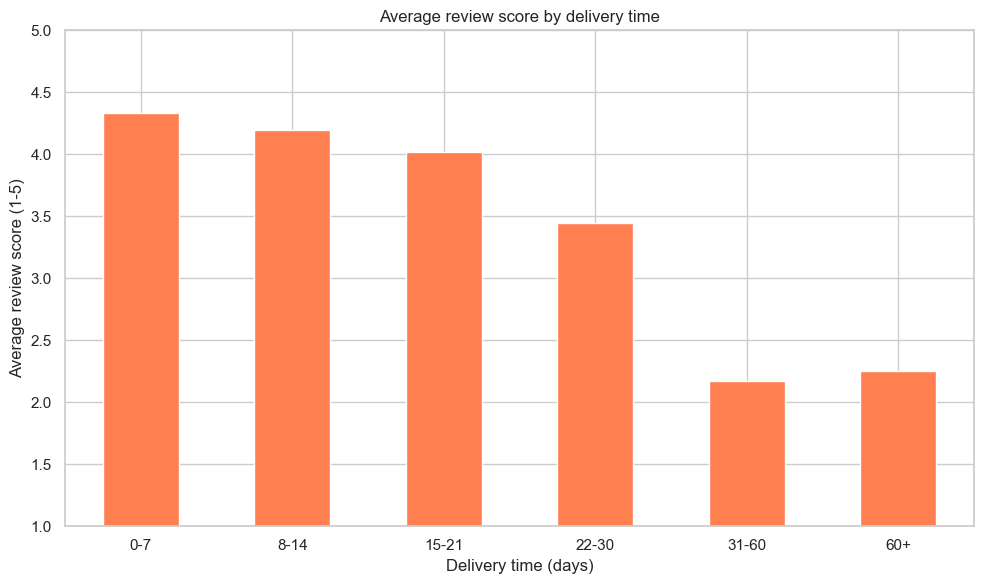

In [58]:
#review score-delivery time
df["delivery_bin"] = pd.cut(
    df["delivery_days"],
    bins=[0, 7, 14, 21, 30, 60, 210],
    labels=["0-7", "8-14", "15-21", "22-30", "31-60", "60+"]
)

avg_score_by_delivery = (
    df.groupby("delivery_bin", observed=True)["review_score"]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 6))
avg_score_by_delivery.plot(kind="bar", ax=ax, color="coral")
ax.set_title("Average review score by delivery time")
ax.set_xlabel("Delivery time (days)")
ax.set_ylabel("Average review score (1-5)")
ax.set_ylim(1, 5)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

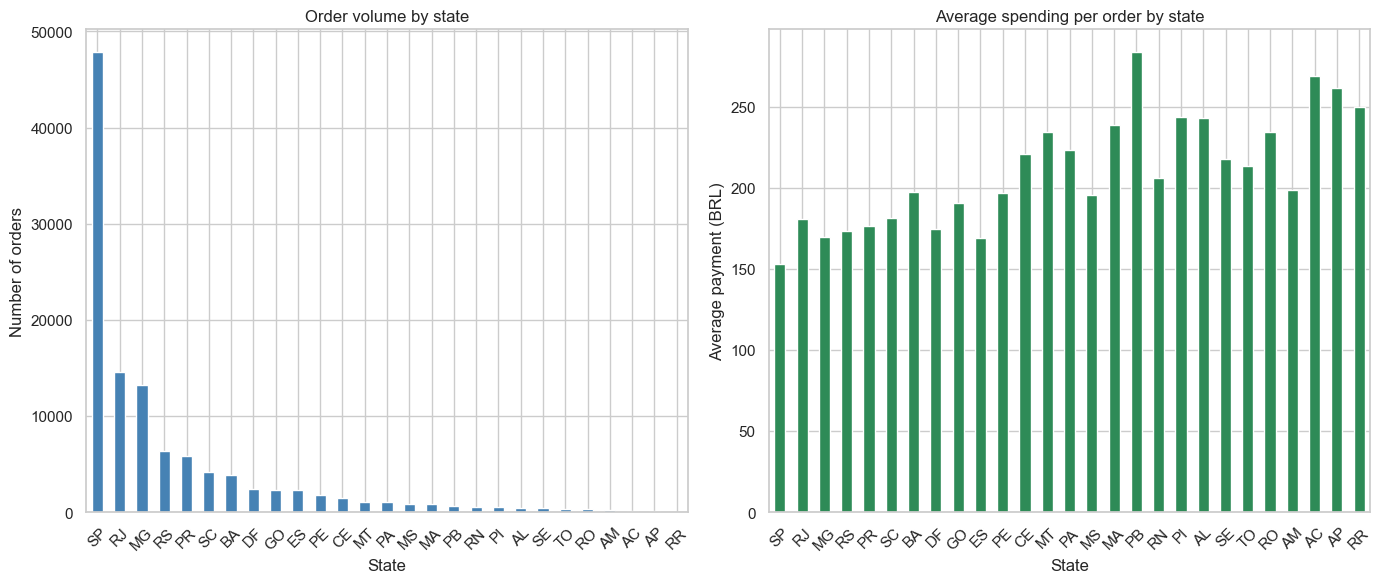

In [59]:
# Order volume and average revenue from different state
state_stats = df.groupby("customer_state").agg(
    order_count=("order_id", "count"),        # number of orders
    avg_spending=("payment_value", "mean")    # average payment/order
).sort_values("order_count", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# order volume/state
state_stats["order_count"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Order volume by state")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Number of orders")
axes[0].tick_params(axis="x", rotation=45)

# average spending/state
state_stats["avg_spending"].plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("Average spending per order by state")
axes[1].set_xlabel("State")
axes[1].set_ylabel("Average payment (BRL)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
#API 
#use openAI to analysis and summary
from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv()

# Prepare key findings
findings = f"""
Here are the key findings from a Brazilian e-commerce dataset analysis:

1. Top 3 revenue categories: {list(revenue_by_category.index[:3])}
   with revenues of {[round(v) for v in revenue_by_category.values[:3]]} BRL

2. Average review scores for top categories range from
   {round(avg_score.min(), 2)} to {round(avg_score.max(), 2)} out of 5.

3. Delivery time and review scores:
   - Orders delivered in 0-7 days average score: {round(avg_score_by_delivery["0-7"], 2)}
   - Orders delivered in 31-60 days average score: {round(avg_score_by_delivery["31-60"], 2)}

4. Top 3 states by order volume: {list(state_stats.index[:3])}
"""

# Send findings and ask for a summary
client = OpenAI() #connect through API key
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {
            "role": "user",
            "content": f"Write a short 3-paragraph summary of these e-commerce analysis findings in plain English:\n{findings}"
        }
    ]
)

ai_summary = response.choices[0].message.content
print(ai_summary)

The analysis of a Brazilian e-commerce dataset reveals some interesting insights into consumer behavior and sales performance. The top three revenue-generating categories are bed, bath, and table items, followed by health and beauty products, and then computers and accessories. These categories generated impressive revenues of approximately 1.7 million, 1.6 million, and 1.5 million BRL, respectively.

When it comes to customer satisfaction, the average review scores for these top categories range from 3.92 to 4.19 out of 5, indicating generally positive feedback from customers. However, there is a notable correlation between delivery times and customer ratings. Orders that were delivered within 0 to 7 days received an average score of 4.33, while those that took 31 to 60 days received a much lower average score of just 2.17, suggesting that faster delivery significantly enhances customer satisfaction.

Geographically, the states with the highest order volumes are São Paulo (SP), Rio de

In [61]:
#export result
# Export cleaned data and analysis results
os.makedirs("output", exist_ok=True)
df.to_csv("output/cleaned_data.csv", index=False)
revenue_by_category.to_csv("output/revenue_by_category.csv", header=["total_revenue"]) #revenue by category
avg_score_by_delivery.to_csv("output/score_by_delivery_time.csv", header=["avg_review_score"]) #delivery time-review score
state_stats.to_csv("output/state_stats.csv") #state
with open("output/ai_summary.txt", "w") as f:
    f.write(ai_summary) #ai summary
print("All results exported to output/")

All results exported to output/


Statement of AI use

Claude was used during this project for troubleshooting, giving refining suggestion after completion,
construct the text:f"""
Here are the key findings from a Brazilian e-commerce dataset analysis:

1. Top 3 revenue categories: {list(revenue_by_category.index[:3])}
   with revenues of {[round(v) for v in revenue_by_category.values[:3]]} BRL

2. Average review scores for top categories range from
   {round(avg_score.min(), 2)} to {round(avg_score.max(), 2)} out of 5.

3. Delivery time and review scores:
   - Orders delivered in 0-7 days average score: {round(avg_score_by_delivery["0-7"], 2)}
   - Orders delivered in 31-60 days average score: {round(avg_score_by_delivery["31-60"], 2)}

4. Top 3 states by order volume: {list(state_stats.index[:3])}
"""  . 

also asked claude the suggestion of image size, such as "(figsize=(10, 6))".
draw the picture for data pipeline overview.
The OpenAI API (gpt-4o-mini) was used in API KEY task.
